In [2]:
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Student_health_data.csv')

In [3]:
df.info()
print(df.isna().sum())
print(df['Sleep Duration'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 18 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   id                                     27901 non-null  int64  
 1   Gender                                 27901 non-null  str    
 2   Age                                    27901 non-null  float64
 3   City                                   27901 non-null  str    
 4   Profession                             27901 non-null  str    
 5   Academic Pressure                      27901 non-null  float64
 6   Work Pressure                          27901 non-null  float64
 7   CGPA                                   27901 non-null  float64
 8   Study Satisfaction                     27901 non-null  float64
 9   Job Satisfaction                       27901 non-null  float64
 10  Sleep Duration                         27901 non-null  str    
 11  Dietary Habit

In [4]:
sleep_duration_fixed = {
    'Less than 5 hours': 'Poor sleep',
    '5-6 hours': 'Average sleep',
    '7-8 hours': 'Good sleep',
    'More than 8 hours': 'Excess sleep',
    'Others': pd.NA
}

df['Sleep Duration'] = df['Sleep Duration'].map(sleep_duration_fixed)

sleep_categories = {
    'Poor sleep' : 1, 
    'Average sleep' : 2, 
    'Good sleep' : 3,
    'Excess sleep' : 4
}

df['sleep_note'] = df['Sleep Duration'].map(sleep_categories)

df = df.dropna(subset=['Sleep Duration', 'sleep_note'])
df.head(10)

,id,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression,sleep_note
0,2,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,Average sleep,Healthy,B.Pharm,Yes,3.0,1.0,No,1,2.0
1,8,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,Average sleep,Moderate,BSc,No,3.0,2.0,Yes,0,2.0
2,26,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Poor sleep,Healthy,BA,No,9.0,1.0,Yes,0,1.0
3,30,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,Good sleep,Moderate,BCA,Yes,4.0,5.0,Yes,1,3.0
4,32,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,Average sleep,Moderate,M.Tech,Yes,1.0,1.0,No,0,2.0
5,33,Male,29.0,Pune,Student,2.0,0.0,5.70,3.0,0.0,Poor sleep,Healthy,PhD,No,4.0,1.0,No,0,1.0
6,52,Male,30.0,Thane,Student,3.0,0.0,9.54,4.0,0.0,Good sleep,Healthy,BSc,No,1.0,2.0,No,0,3.0
7,56,Female,30.0,Chennai,Student,2.0,0.0,8.04,4.0,0.0,Poor sleep,Unhealthy,Class 12,No,0.0,1.0,Yes,0,1.0
8,59,Male,28.0,Nagpur,Student,3.0,0.0,9.79,1.0,0.0,Good sleep,Moderate,B.Ed,Yes,12.0,3.0,No,1,3.0
9,62,Male,31.0,Nashik,Student,2.0,0.0,8.38,3.0,0.0,Poor sleep,Moderate,LLB,Yes,2.0,5.0,No,1,1.0


## Is depression affecting these people's sleep?

First we set the null hypothesis that there is no difference in sleep between the people with and without depression

In [5]:
df_depression_sleep = df.copy()

with_depression = df_depression_sleep[df_depression_sleep['Depression'] == 1]['sleep_note'].tolist()
without_depression = df_depression_sleep[df_depression_sleep['Depression'] == 0]['sleep_note'].tolist()

u_stat, p_value = stats.mannwhitneyu(without_depression, with_depression, alternative='two-sided')

print(f"The p-value is: {p_value:.50f}")

The p-value is: 0.00000000000000000000000000000000000000000000000447


## Results of the test

As we can see the Mann Whiteny u test reutrned the p-value of 0.00000000...447 which is significantly lower than the 0.05 treshold. Therefore, we can confidently reject the null hypothesis that there is no difference between the people with depression and the ones without depression. The result suggests that there is a statistically significant relationship between depression and the sleep of the students.

---

# Visualisation and charts

Here we will make a chart to actually visualise how our data looks

/var/folders/81/vryb8mxs5flbzq30685135180000gn/T/ipykernel_27509/1579135913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression', y='sleep_note', data=df_depression_sleep, palette=['#2ecc71', '#e74c3c'])


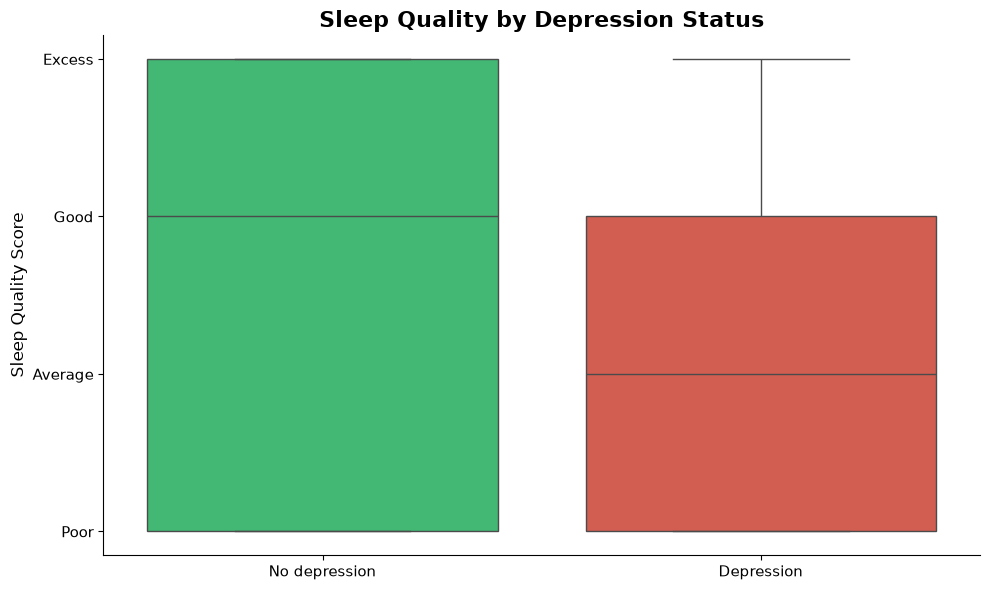

In [31]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='Depression', y='sleep_note', data=df_depression_sleep, palette=['#2ecc71', '#e74c3c'])
plt.title("Sleep Quality by Depression Status", fontsize = 16, fontweight = 'bold')
plt.ylabel("Sleep Quality Score", fontsize = 12)
plt.xlabel('')
plt.xticks([0, 1], ['No depression', 'Depression'], fontsize = 11)
plt.yticks([1, 2, 3, 4], ['Poor', 'Average', 'Good', 'Excess'], fontsize = 11)
sns.despine()
plt.tight_layout()
plt.show()

## Chart findings

Students without depression showed a median value of 3 (Good sleep) whereas students with depression showed a median value of 2 (Average sleep), that shows a 1 full category jump. What is really interesting about this is the fact that the data shows that 25% of people with no depression still have poor sleep but the data has a wide spread up untill the 4th category on the people without depression compared to the students with depression that have the spread finishing at 3 so the cases where they get good sleep are poor. With this chart and with the Mann Whiteny u test that we ran earlier, again, we can confidently say that there is a statistically significant difference between them which the chart provides in the image above.

---

# Do students without depression show a higher CGPA than the students with depression?

Of course we will first set the null hypothesis that there is no difference in CGPA between the students with depression and the students without depression. We will run the Mann Whiteny U test on these here too because first of all this is a practice dataset and second of all i do not know for sure if the CGPA is normally distributed across all the students.


In [19]:
df_cgpa_depression = df.copy()

cgpa_with_depression = df_cgpa_depression[df_cgpa_depression['Depression'] == 1]['CGPA'].tolist()
cgpa_without_depression = df_cgpa_depression[df_cgpa_depression['Depression'] == 0]['CGPA'].tolist()

u_test, p_value = stats.mannwhitneyu(cgpa_without_depression, cgpa_with_depression, alternative='two-sided')

print(f"The p-value is: {p_value:.5f}")

The p-value is: 0.00032


## Findings

We can definetely see that the Mann Whiteny U test returned a p-value of 0.00032 which is significantly lower than the 0.05 treshold. With the data provided, we can confidently reject the null hypothesis stating that "there is no difference in CGPA between the students with depression and the students without depression" and see that there is a statistically significant difference between these students.

---

# Visual representation and conclusion

Given the fact that we used the Mann Whiteny U test, we will use a boxplot to see our data so that we can see the median in CGPA for each group and than write our conclusion.

/var/folders/81/vryb8mxs5flbzq30685135180000gn/T/ipykernel_27509/329689470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Depression', y='CGPA', data=df_cgpa_depression, palette = ['#2ecc71', '#e74c3c'], legend=False)


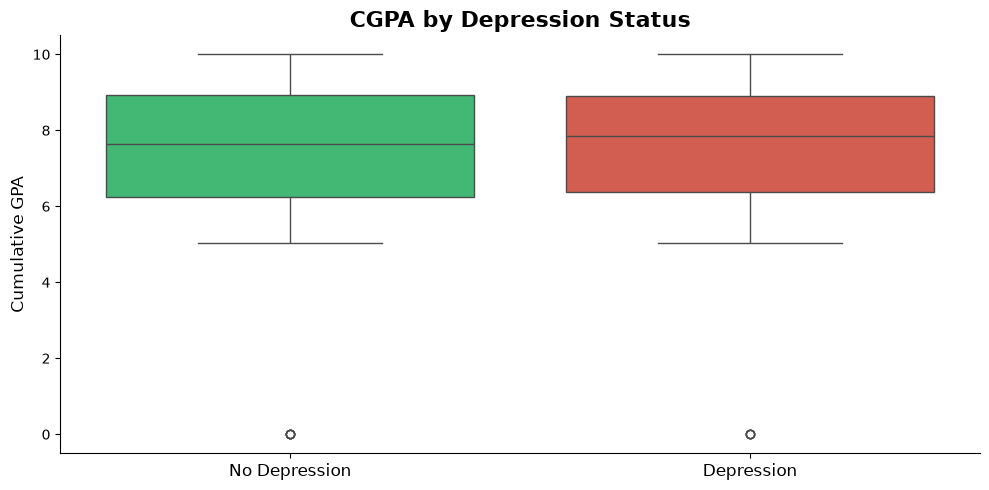

In [ ]:
fig, ax = plt.subplots(figsize = (10, 5))
sns.boxplot(x='Depression', y='CGPA', data=df_cgpa_depression, palette = ['#2ecc71', '#e74c3c'], legend=False)
plt.title("CGPA by Depression Status", fontsize = 16, fontweight = 'bold')
plt.ylabel("Cumulative GPA", fontsize = 12)
plt.xlabel('')
plt.xticks([0, 1], ['No Depression', 'Depression'], fontsize = 12)
sns.despine()
plt.tight_layout()
plt.show()


## Chart findings and conclusion

The Mann Whiteny U test returned a p-value of 0.00032 which indicates that there is a statistically significant difference between the students with depression and the students without depression. The boxplot above on the other hand, shows a difference of approximately 0.3 between the medians of the CGPA from people with depression and CGPA from people without depression which is a minimal difference. This suggest that altough the difference is real, it is not meaningful and in a real-world case. This might be due to the large sample the test was ran on, inflicting statistical sensitivity.
